# Faster R-CNN — Custom Train, Baseline-like Test Metrics (COCOeval)

This notebook provides an end-to-end Faster R-CNN workflow: a **custom training routine** and a **baseline-compatible COCO evaluation**, so results can be compared fairly while keeping the training strategy intentionally non-identical.


**Goal:** Keep the *evaluation protocol* consistent with the baseline while exploring a *different training strategy*.

Just update the paths in `CONFIG` accordingly.


In [1]:
# ============================================================
# 0) Imports / environment
# ============================================================
# !pip -q install pycocotools

import os, json, time, random, math
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
device: cuda


## 1) Configuration and Hyperparameters

Here, all training and evaluation parameters are defined in a central configuration block. This includes dataset paths, batch size, number of epochs, learning rate, and evaluation thresholds.

Centralising these parameters improves experiment transparency, simplifies reproducibility, and makes it easier to analyse the impact of individual hyperparameters on model performance.

In [ ]:
@dataclass
class Config:
      # notebook/ -> ../dataset/splitted_coco_dataset
    dataset_root: str = os.path.join("..", "dataset", "splitted_coco_dataset")

    train_img_dir: str = os.path.join(dataset_root, "train", "images")
    train_ann_file: str = os.path.join(dataset_root, "train", "annotations.json")

    use_val: bool = False
    val_img_dir: str = os.path.join(dataset_root, "val", "images")
    val_ann_file: str = os.path.join(dataset_root, "val", "annotations.json")

    test_img_dir: str = os.path.join(dataset_root, "test", "images")
    test_ann_file: str = os.path.join(dataset_root, "test", "annotations.json")

    # training hyperparams (custom vs baseline)(i keep batch_size small and num_workers=0 for less memory issues u may increase it)
    epochs: int = 12
    batch_size: int = 2
    num_workers: int = 0

    lr: float = 3e-4
    weight_decay: float = 1e-4

    # custom choices (different from many baselines)
    optimizer: str = "adamw"  # 'adamw' or 'sgd'
    use_amp: bool = True
    grad_clip_norm: float = 1.0  # 0 to disable

    # light augment (optional)
    random_hflip_p: float = 0.5  # 0 disables

    # eval
    EVAL_STRICT_BASELINE: bool = True
    score_threshold: float = 0.5

    out_dir: str = "outputs"
    save_name: str = "fasterrcnn_custom_train.pth"

    seed: int = 42

cfg = Config()
os.makedirs(cfg.out_dir, exist_ok=True)
print(cfg)


Config(dataset_root='..\\dataset\\splitted_coco_dataset', train_img_dir='..\\dataset\\splitted_coco_dataset\\train\\images', train_ann_file='..\\dataset\\splitted_coco_dataset\\train\\annotations.json', use_val=False, val_img_dir='..\\dataset\\splitted_coco_dataset\\val\\images', val_ann_file='..\\dataset\\splitted_coco_dataset\\val\\annotations.json', test_img_dir='..\\dataset\\splitted_coco_dataset\\test\\images', test_ann_file='..\\dataset\\splitted_coco_dataset\\test\\annotations.json', epochs=12, batch_size=2, num_workers=0, lr=0.0003, weight_decay=0.0001, optimizer='adamw', use_amp=True, grad_clip_norm=1.0, random_hflip_p=0.5, EVAL_STRICT_BASELINE=True, score_threshold=0.5, out_dir='outputs', save_name='fasterrcnn_custom_train.pth', seed=42)


## 2) Seed

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


## 3) Dataset

The training and test datasets are loaded using a custom COCO-compatible dataset class. Each sample consists of an image and its corresponding bounding box annotations.

Using a COCO-based dataset structure ensures compatibility with standard evaluation tools and allows consistent handling of class labels and annotations.


In [4]:
class COCODetectionDataset(Dataset):
    def __init__(self, img_dir: str, ann_file: str, hflip_p: float = 0.0):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.img_ids = sorted(self.coco.getImgIds())

        # COCO category ids (as in json)
        self.cat_ids = sorted(self.coco.getCatIds())
        # map category_id -> contiguous label (1..K)
        self.cat_id_to_label = {cat_id: i+1 for i, cat_id in enumerate(self.cat_ids)}
        self.label_to_cat_id = {v: k for k, v in self.cat_id_to_label.items()}

        self.hflip_p = hflip_p

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            x, y, w, h = a["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x + w, y + h])

            cat_id = a["category_id"]
            labels.append(self.cat_id_to_label[cat_id])  # 1..K

            areas.append(a.get("area", w * h))
            iscrowd.append(a.get("iscrowd", 0))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image_t = F.to_tensor(image)

        # optional random horizontal flip (custom train choice)
        if self.hflip_p > 0 and random.random() < self.hflip_p:
            _, h_img, w_img = image_t.shape
            image_t = torch.flip(image_t, dims=[2])
            if boxes.numel() > 0:
                x1 = boxes[:, 0].clone()
                x2 = boxes[:, 2].clone()
                boxes[:, 0] = w_img - x2
                boxes[:, 2] = w_img - x1
                target["boxes"] = boxes

        return image_t, target

def collate_fn(batch):
    return tuple(zip(*batch))


## 4) DataLoaders

In [5]:
train_ds = COCODetectionDataset(cfg.train_img_dir, cfg.train_ann_file, hflip_p=cfg.random_hflip_p)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, collate_fn=collate_fn)

val_loader = None
if cfg.use_val:
    val_ds = COCODetectionDataset(cfg.val_img_dir, cfg.val_ann_file, hflip_p=0.0)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                            num_workers=cfg.num_workers, collate_fn=collate_fn)

test_ds = COCODetectionDataset(cfg.test_img_dir, cfg.test_ann_file, hflip_p=0.0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                         num_workers=cfg.num_workers, collate_fn=collate_fn)

num_classes = len(train_ds.cat_ids) + 1
print("train:", len(train_ds), "test:", len(test_ds), "num_classes:", num_classes)


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
train: 8008 test: 1002 num_classes: 23


## 5) Build Faster R-CNN

A Faster R-CNN model with a ResNet-50 backbone and Feature Pyramid Network (FPN) is instantiated. The classification head is adapted to match the number of insect categories in the dataset.

This architecture was selected due to its strong performance in object detection tasks and its ability to capture multi-scale features, which is particularly relevant for insect detection.

### Optimisation Strategy

The training process is configured using the AdamW optimizer, a learning rate scheduler, and automatic mixed precision (AMP).

These choices improve convergence stability, reduce training time, and allow more efficient use of GPU resources without changing the model architecture.


In [6]:
def build_model(num_classes: int):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(num_classes).to(device)

# custom optimizer/scheduler (train differs from baseline)
params = [p for p in model.parameters() if p.requires_grad]

if cfg.optimizer.lower() == "adamw":
    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
else:
    optimizer = torch.optim.SGD(params, lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay)

# cosine scheduler (custom)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))

print("model/optimizer ready")


model/optimizer ready


C:\Users\ofaru\AppData\Local\Temp\ipykernel_16892\2127110403.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device.type == "cuda"))


In [7]:
print("len(train_loader):", len(train_loader))

len(train_loader): 4004


## 6) Model Training

The model is trained for multiple epochs over the full training dataset. During training, loss values are logged to monitor convergence behaviour.

Each epoch represents one complete pass over the dataset, enabling the model to progressively refine its object detection and classification capabilities.

### Training Loop

This section defines the training loop for a single epoch. The model processes batches of images, computes detection losses, and updates parameters via backpropagation.

Gradient clipping and mixed-precision training are applied to stabilise optimisation and prevent exploding gradients during training.

In [8]:
def train_one_epoch(model, loader, optimizer, scaler, device, epoch, print_freq=50):
    model.train()
    running = 0.0
    n = 0
    t0 = time.time()

    for i, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
            loss_dict = model(images, targets)
            loss = sum(v for v in loss_dict.values())

        scaler.scale(loss).backward()

        if cfg.grad_clip_norm and cfg.grad_clip_norm > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)

        scaler.step(optimizer)
        scaler.update()

        lv = float(loss.item())
        running += lv
        n += 1

        if (i + 1) % print_freq == 0:
            dt = time.time() - t0
            print(f"epoch {epoch} step {i+1}/{len(loader)} loss {lv:.4f} time {dt:.1f}s")

    return running / max(n, 1)

loss_history = []
for epoch in range(1, cfg.epochs + 1):
    avg_loss = train_one_epoch(model, train_loader, optimizer, scaler, device, epoch, print_freq=25)
    scheduler.step()
    loss_history.append(avg_loss)
    print(f"✅ epoch {epoch}/{cfg.epochs} | avg loss: {avg_loss:.4f} | lr: {optimizer.param_groups[0]['lr']:.6g}")


C:\Users\ofaru\AppData\Local\Temp\ipykernel_16892\463037241.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch 1 step 25/4004 loss 0.2218 time 8.0s
epoch 1 step 50/4004 loss 0.2562 time 13.9s
epoch 1 step 75/4004 loss 0.0535 time 19.7s
epoch 1 step 100/4004 loss 0.2952 time 25.5s
epoch 1 step 125/4004 loss 0.4141 time 31.3s
epoch 1 step 150/4004 loss 0.1722 time 37.4s
epoch 1 step 175/4004 loss 0.1153 time 43.8s
epoch 1 step 200/4004 loss 0.3026 time 50.0s
epoch 1 step 225/4004 loss 4.1973 time 56.2s
epoch 1 step 250/4004 loss 0.0081 time 62.5s
epoch 1 step 275/4004 loss 0.2909 time 68.7s
epoch 1 step 300/4004 loss 0.2740 time 74.9s
epoch 1 step 325/4004 loss 0.1676 time 81.2s
epoch 1 step 350/4004 loss 0.2416 time 87.6s
epoch 1 step 375/4004 loss 0.2471 time 94.1s
epoch 1 step 400/4004 loss 0.3068 time 100.5s
epoch 1 step 425/4004 loss 0.1207 time 107.1s
epoch 1 step 450/4004 loss 0.1360 time 113.9s
epoch 1 step 475/4004 loss 0.0201 time 120.7s
epoch 1 step 500/4004 loss 0.1207 time 127.7s
epoch 1 step 525/4004 loss 0.0909 time 134.7s
epoch 1 step 550/4004 loss 0.1077 time 141.6s
epoch 1

## 7) Save model

In [9]:
save_path = os.path.join(cfg.out_dir, cfg.save_name)
torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes": num_classes,
    "cat_ids": train_ds.cat_ids,
    "cat_id_to_label": train_ds.cat_id_to_label,
    "label_to_cat_id": train_ds.label_to_cat_id,
}, save_path)
print("saved:", save_path)


saved: outputs\fasterrcnn_custom_train.pth


## 8) Test Evaluation Setup

After training, the model is switched to evaluation mode and tested on a held-out test dataset. Predictions are collected and converted into COCO-compatible result formats.

This separation between training and testing ensures that evaluation results reflect the model’s generalisation ability rather than memorisation.


In [16]:
import matplotlib.pyplot as plt

def plot_overall_coco_metrics(coco_eval):
    labels = ["AP@[0.50:0.95]", "AP@0.50", "AP@0.75", "AR@1", "AR@10", "AR@100"]
    values = [coco_eval.stats[0], coco_eval.stats[1], coco_eval.stats[2],
              coco_eval.stats[6], coco_eval.stats[7], coco_eval.stats[8]]

    plt.figure(figsize=(8,4))
    plt.bar(labels, values)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Overall COCO Metrics")
    plt.tight_layout()
    plt.show()

def plot_per_class_ap(cat_names, ap_values):
    plt.figure(figsize=(14,5))
    plt.bar(range(len(ap_values)), ap_values)
    plt.xticks(range(len(ap_values)), cat_names, rotation=90)
    plt.ylim(0, 1.0)
    plt.ylabel("AP@[0.50:0.95]")
    plt.title("Per-class AP (COCO)")
    plt.tight_layout()
    plt.show()


### Evaluation Metrics and Protocol

Model performance is evaluated using the COCO object detection metrics. These metrics were selected to provide a comprehensive and interpretable assessment of detection quality.

The primary metric, **AP@[0.50:0.95]**, measures average precision across multiple Intersection-over-Union (IoU) thresholds, balancing both detection accuracy and localisation quality.  
Additional metrics such as **AP@0.50** and **AP@0.75** provide insight into coarse versus strict localisation performance.

Using multiple metrics avoids relying on a single numerical value and enables a clearer understanding of how the model behaves under different evaluation assumptions.

### Per-Class Performance Analysis

Beyond overall performance, evaluation is performed on a per-class basis. This analysis reveals how well the model performs for individual insect categories.

Per-class metrics are essential for identifying class-specific weaknesses, dataset imbalance effects, and visually similar classes that may be harder to distinguish.



Running TEST evaluation + graphs...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.15s).

=== OVERALL SCORES (ALL CLASSES) ===
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.629
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.708
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.690
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.539
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.614
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.731
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 

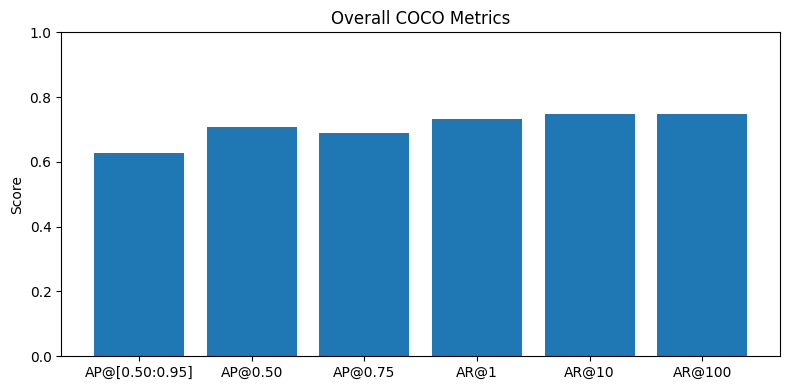


=== PER-CLASS AP ===
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.00s).
Class 0 (1912): AP@[0.50:0.95] = 0.904
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.01s).
Class 1 (2351): AP@[0.50:0.95] = 0.263
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.14s).
Accumulating evaluation results...
DONE (t=0.01s).
Class 2 (2357): AP@[0.50:0.95] = 0.664
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
Class 3 (2358): AP@[0.50:0.95] = 0.728
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
Class 4 (2392): AP@[0.50:0.95] = 0.327
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s

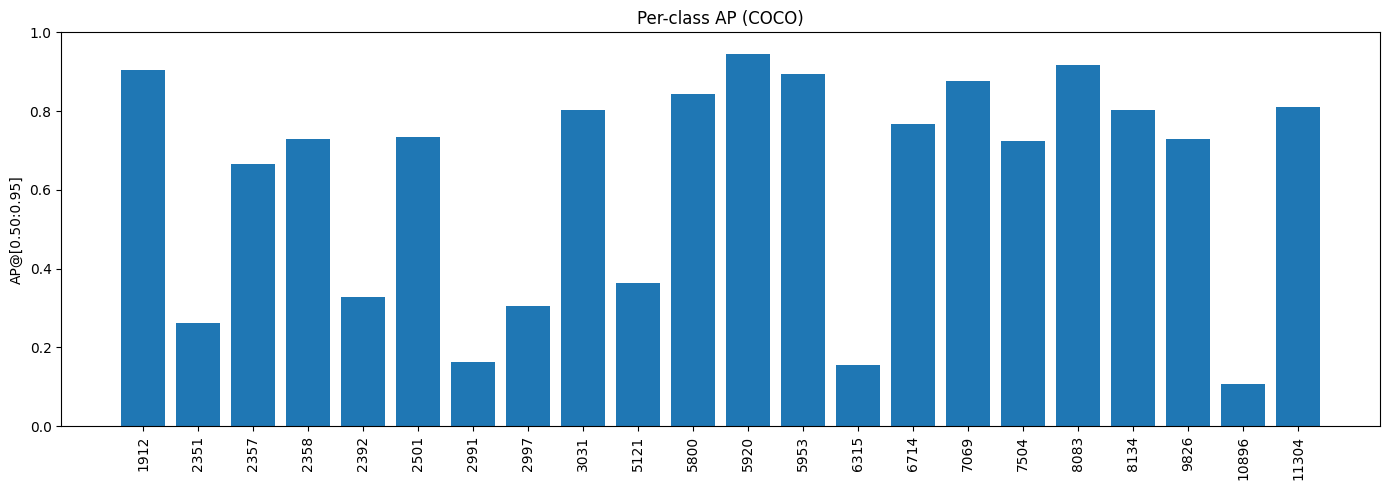

In [18]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import torch
from torch.utils.data import DataLoader
import io, contextlib

def evaluate_test_and_plot(model, dataset, ann_file, device,
                           score_threshold=0.5,
                           strict_baseline=True,
                           label_to_cat_id=None):

    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
    coco_gt = COCO(ann_file)

    coco_gt.dataset.setdefault("info", {})
    coco_gt.dataset.setdefault("licenses", [])

    coco_results = []

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            image_ids = [int(t["image_id"].item()) for t in targets]

            outputs = model(images)

            for output, img_id in zip(outputs, image_ids):
                boxes = output["boxes"].cpu()
                scores = output["scores"].cpu()
                labels = output["labels"].cpu()

                for box, score, label in zip(boxes, scores, labels):
                    if float(score) < score_threshold:
                        continue

                    x1, y1, x2, y2 = box.tolist()

                    # IMPORTANT: baseline-style mapping
                    if strict_baseline:
                        category_id = int(label) - 1
                    else:
                        if label_to_cat_id is None:
                            raise ValueError("label_to_cat_id is required when strict_baseline=False")
                        category_id = int(label_to_cat_id[int(label)])

                    coco_results.append({
                        "image_id": img_id,
                        "category_id": category_id,
                        "bbox": [x1, y1, x2 - x1, y2 - y1],
                        "score": float(score)
                    })

    coco_dt = coco_gt.loadRes(coco_results)

    # ---- Overall COCOeval ----
    coco_eval_all = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval_all.evaluate()
    coco_eval_all.accumulate()

    print("\n=== OVERALL SCORES (ALL CLASSES) ===")
    coco_eval_all.summarize()

    # Overall metrics graph
    plot_overall_coco_metrics(coco_eval_all)

    # ---- Per-class AP ----
    cat_ids = coco_gt.getCatIds()
    cat_info = {c["id"]: c.get("name", str(c["id"])) for c in coco_gt.loadCats(cat_ids)}

    cat_names = []
    ap_values = []

    print("\n=== PER-CLASS AP ===")
    for catId in cat_ids:
        coco_eval_cls = COCOeval(coco_gt, coco_dt, "bbox")
        coco_eval_cls.params.catIds = [catId]
        coco_eval_cls.evaluate()
        coco_eval_cls.accumulate()

        # IMPORTANT: stats[] is filled by summarize(); suppress its verbose print
        with contextlib.redirect_stdout(io.StringIO()):
            coco_eval_cls.summarize()

        ap = float(coco_eval_cls.stats[0])  # AP@[0.50:0.95]
        name = cat_info.get(catId, str(catId))

        cat_names.append(name)
        ap_values.append(ap)

        print(f"Class {catId} ({name}): AP@[0.50:0.95] = {ap:.3f}")

    # Per-class graph
    plot_per_class_ap(cat_names, ap_values)

    return {"cat_names": cat_names, "ap_values": ap_values, "overall": coco_eval_all.stats}

print("Running TEST evaluation + graphs...")
results = evaluate_test_and_plot(
    model=model,
    dataset=test_ds,
    ann_file=cfg.test_ann_file,
    device=device,
    score_threshold=cfg.score_threshold,
    strict_baseline=cfg.EVAL_STRICT_BASELINE,
    label_to_cat_id=train_ds.label_to_cat_id
)


## 9)Results and Performance Analysis

### Overall performance
The overall evaluation indicates that the model achieves a solid detection performance under the COCO evaluation protocol. The **AP@[0.50:0.95]** score suggests that the model is able to balance object localisation and classification across multiple IoU thresholds, rather than optimising for a single overlap criterion.

The gap between **AP@0.50** and **AP@0.75** highlights the difference between coarse object detection and precise localisation. While the model performs well at lower IoU thresholds, stricter localisation requirements expose limitations in bounding box accuracy for certain instances.

### Class-wise performance analysis

A per-class evaluation reveals notable variability across insect categories. Several classes achieve consistently high average precision, indicating that the model is able to learn stable and discriminative visual features for these insects. These classes typically correspond to insects with more distinctive shapes, textures, or consistent visual appearance across samples.

In contrast, other classes show significantly lower AP values. This behaviour suggests that these categories are either visually similar to other classes, underrepresented in the dataset, or more affected by scale and background variation. The observed performance gap indicates that the model does not treat all insect categories equally and that class-specific challenges play a substantial role.


### Influence of object scale

The evaluation further shows reduced performance for smaller objects. This limitation is particularly relevant for insect detection, where many targets occupy only a small portion of the image.

Lower scores for certain classes can therefore be partially attributed to scale-related challenges, rather than purely semantic confusion. This observation aligns with known limitations of two-stage detectors and highlights the importance of scale-aware strategies in future improvements.


### Visual interpretation of results

The visualisations of per-class average precision provide an intuitive comparison of model behaviour across categories. Instead of relying solely on numerical tables, the bar charts clearly highlight performance disparities and make it easier to identify both strong and weak classes.

These visual results support a more transparent interpretation of the metrics and help connect quantitative scores to qualitative model behaviour.


### Interpretation and limitations

Overall, the results indicate that the model successfully learns object-level representations for several insect classes but struggles with others due to scale, visual similarity, or dataset imbalance. Importantly, these limitations become visible only when examining class-wise and scale-aware metrics, rather than relying on a single overall score.

This reinforces the importance of using multiple evaluation metrics and explicit justification of their purpose, as discussed earlier in the evaluation protocol.


## 10) Overall conclusion

In summary, the evaluation demonstrates that while the Faster R-CNN model provides strong baseline performance, its effectiveness varies significantly across classes and object scales. The results underline the need for class-aware analysis and motivate further investigation into robustness, data balancing, and alternative architectural strategies.

By combining numerical metrics with visual analysis and class-wise interpretation, the evaluation provides a more complete and transparent understanding of model performance beyond raw scores.
